In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")
import jax
print(jax.devices()) 

ERROR:2026-01-23 17:03:49,430:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


[CpuDevice(id=0)]


In [3]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
import equinox as eqx
import matplotlib.pyplot as plt
import time

from ABCMB import main, background, perturbations, spectrum, model_specs, species
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

In [4]:
from pytests import accuracy_test

# Bessel

In [14]:
from scipy.special import spherical_jn

In [11]:
def Q(l, x):
    return jnp.where(
        x > l,
        jnp.sqrt(x**2 - l**2) - jnp.pi*l/2. + l*jnp.arcsin(l/x),
        0.
    )

def J(l, x):
    return jnp.sqrt(2/jnp.pi/jnp.sqrt(x**2-l**2)) * jnp.cos(Q(l, x) - jnp.pi/4.)

def j(l, x):
    return jnp.sqrt(jnp.pi/2./x)*J(l+1/2, x)

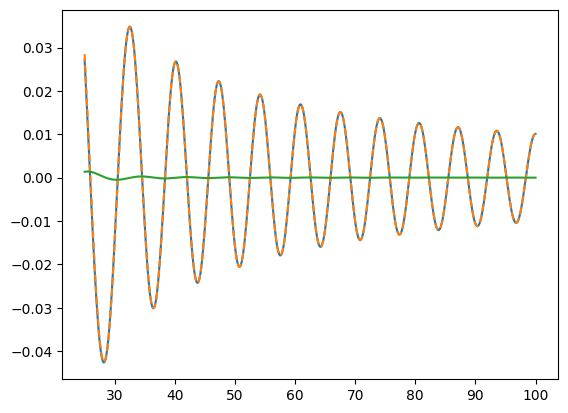

In [38]:
l = 20
x = jnp.linspace(25, 100, 500)
plt.plot(x, j(l, x))
plt.plot(x, spherical_jn(l, x), "--")
plt.plot(x, spherical_jn(l, x) - j(l, x))
plt.show()

In [58]:
spectrum.bessel_x_tab[-1]

Array(5000., dtype=float64)

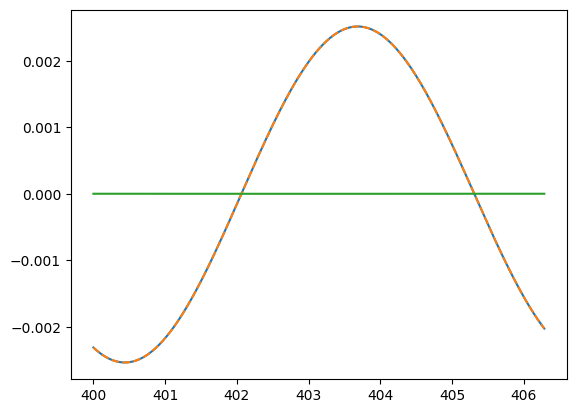

In [54]:
# Period of bessel is just about 2pi
l = 100
x = jnp.linspace(l+300, l+300+2.*jnp.pi, 500)
plt.plot(x, j(l, x))
plt.plot(x, spherical_jn(l, x), "--")
plt.plot(x, spherical_jn(l, x) - j(l, x))
plt.show()

# Setup

In [26]:
"""
params = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.71636,
    #'N_nu_massless' : 3,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}
"""
"""
params = {
    'h': 0.6,
    'omega_cdm': 0.08,
    'omega_b': 0.01,
    'A_s': 1.e-9,
    'n_s': 0.9,
    'Neff': 3.044,
    'YHe': 0.2,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.71636,
    #'N_nu_massless' : 3,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 5.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}
"""

params = {
    'h': 0.6611+10.*0.0079,
    'omega_cdm': 0.1238+10*0.0021,
    'omega_b': 0.02259+10*0.00017,
    'A_s': 2.12e-9,
    'n_s': 0.9666+10.*0.0077,
    'Neff': 3.044,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.71636,
    #'N_nu_massless' : 3,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

lmax = 2500
specs = {
    "output_Cl" : True,
    "l_max" : lmax,
    "lensing" : True,
    "output_Pk" : True,
    "output_k_max" : 0.5,
    "bbn_type" : "table",
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17,
    "l_max_ncdm" : 17,
    "output_background" : True,
    "output_perturbations" : True,
    "scale_sw" : 1.,
    "scale_isw" : 1.,
    "scale_dop" : 1.,
    "scale_pol" : 1.
}
if params["N_nu_massive"] > 0:
    user_species = (
        species.MassiveNeutrino,
    )
else:
    user_species = None

#model = main.Model(user_species=user_species, input_specs=specs, return_PTBG=True, bbn_type="linX")
model = main.Model(user_species=user_species, input_specs=specs)

In [28]:
for i in range(2):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      

269.61654138565063
98.80608892440796


In [8]:
params = label[-3]
PT = label[-2]
BG = label[-1]

In [29]:
class_times2 = np.zeros(1)
for i in range(1):
    class_params = {
        "output": "mPk, tCl, pCl, lCl" if specs["lensing"] else "mPk, tCl, pCl",
        #"temperature_contributions" : "tsw",
        "P_k_max_1/Mpc" : specs["output_k_max"],
        "l_max_scalars" : lmax,
        "k_output_values" : "7.04886556e-06",
        "lensing" : "yes" if specs["lensing"] else "no",
        "H0": params["h"]*100,
        "omega_b": params["omega_b"],
        "omega_cdm": params["omega_cdm"],
        "A_s" : params["A_s"],
        "n_s" : params["n_s"],
        "N_ur": params["Neff"],
        #"YHe": params["YHe"],
        "YHe": "bbn",
        "N_ncdm": params["N_nu_massive"],
        #"reio_parametrization" : "reio_none",
        "reio_parametrization" : "reio_camb",
        "z_reio" : params["z_reion"],
        "reionization_width" : params["Delta_z_reion"],
        "helium_fullreio_redshift" : params["z_reion_He"],
        "helium_fullreio_width" : params["Delta_z_reion_He"],
        "reionization_exponent" : 1.5,
        "l_max_g": specs["l_max_g"],
        "l_max_pol_g": specs["l_max_pol_g"],
        "l_max_ur": specs["l_max_ur"], 
        "l_max_ncdm":specs["l_max_ncdm"]}
        #"radiation_streaming_trigger_tau_over_tau_k" : 20000,
        #"radiation_streaming_trigger_tau_c_over_tau" : 2000,
        #"ur_fluid_trigger_tau_over_tau_k" : 10000, 
        #"ncdm_fluid_trigger_tau_over_tau_k" : 15000} 
    class_lcdm = Class()
    class_lcdm.set(class_params)
    if params["N_nu_massive"] > 0:
        class_lcdm.set({"m_ncdm": params["m_nu_massive"], "T_ncdm": params["T_nu_massive"]})
    s = time.time()
    class_lcdm.compute()
    rtime = time.time() - s
    print(rtime)
    class_times2[i] = rtime

4.904769659042358


In [60]:
mean = np.mean(class_times)
sigma = np.sqrt(np.sum((class_times-mean)**2)/class_times.size)
print(mean)
print(sigma)

5.329793262481689
0.029392389918109846


In [62]:
mean2 = np.mean(class_times2)
sigma2 = np.sqrt(np.sum((class_times2-mean2)**2)/class_times2.size)
print(mean2)
print(sigma2)

25.993018245697023
0.03971500048926677


# Background Check

## Hubble

In [212]:
class_bg = class_lcdm.get_background()
BG = label[4]
a = 1/(1.+class_bg["z"])
H_class = class_bg['H [1/Mpc]'] * cnst.c_Mpc_over_s
H_ABCMB = BG.H(jnp.log(a), params)
plt.plot(a, abs(H_class - H_ABCMB)/H_class)
plt.yscale("symlog")
plt.xscale("log")
plt.show()

KeyError: 'omega_Lambda'

## Massive Neutrino Density

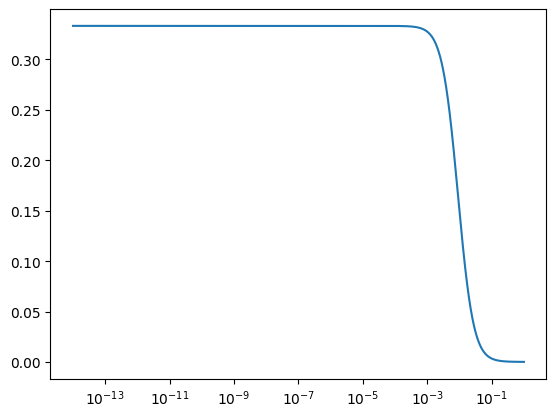

In [15]:
rho_nu_class = class_bg[ '(.)p_ncdm[0]']/class_bg[ '(.)rho_ncdm[0]']
plt.plot(a, rho_nu_class)
#rho_nu_ABCMB = BG.H(jnp.log(a), params)
#plt.plot(a, (H_class - H_ABCMB)/H_class)
#plt.yscale("symlog")
#plt.xscale("log")
#plt.xlim((1.e-5, 1.))
plt.xscale("log")
plt.show()

# Thermodynamics Check

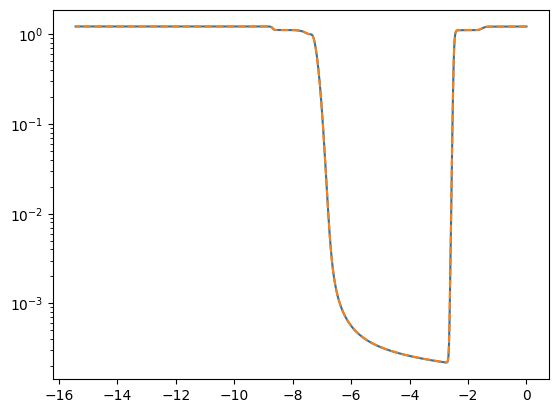

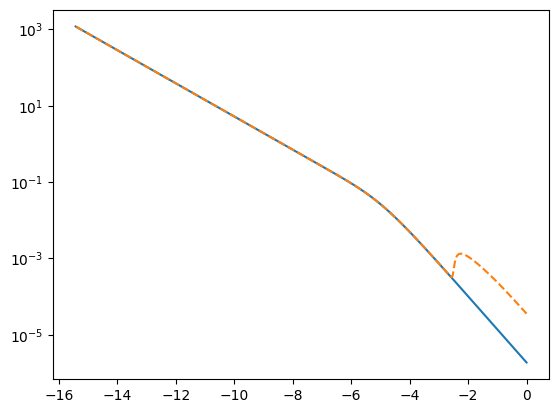

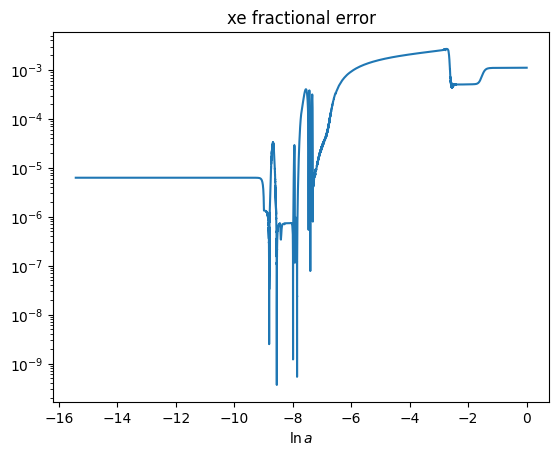

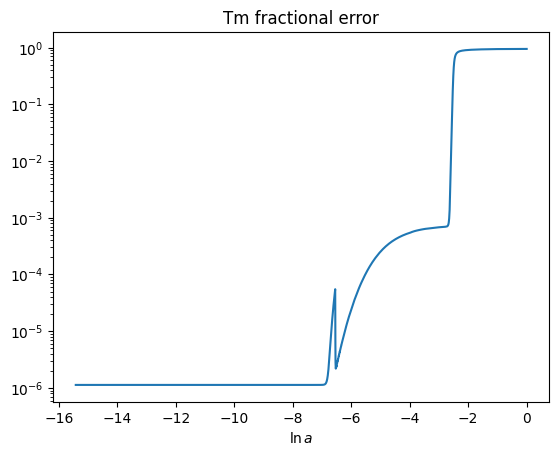

In [220]:
class_rec = class_lcdm.get_thermodynamics()
a = 1/(1.+class_rec["z"])
xe_class = class_rec["x_e"]
Tm_class = class_rec['Tb [K]'] * cnst.kB
xe_abcmb = BG.xe(jnp.log(a))
Tm_abcmb = BG.Tm(jnp.log(a), params)

plt.plot(jnp.log(a), xe_abcmb)
plt.plot(jnp.log(a), xe_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), Tm_abcmb)
plt.plot(jnp.log(a), Tm_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(xe_abcmb-xe_class)/xe_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("xe fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(Tm_abcmb-Tm_class)/Tm_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Tm fractional error")
plt.show()

In [221]:
expmkappa_class = class_rec["exp(-kappa)"]
g_class = class_rec["g [Mpc^-1]"]
expmkappa_abcmb = vmap(BG.expmkappa)(jnp.log(a))
g_abcmb = vmap(BG.visibility, in_axes=(0, None))(jnp.log(a), params)

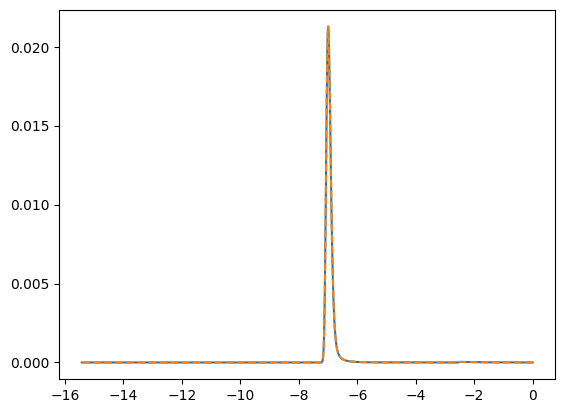

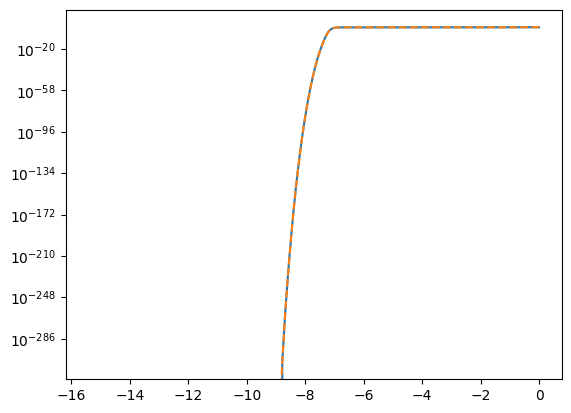

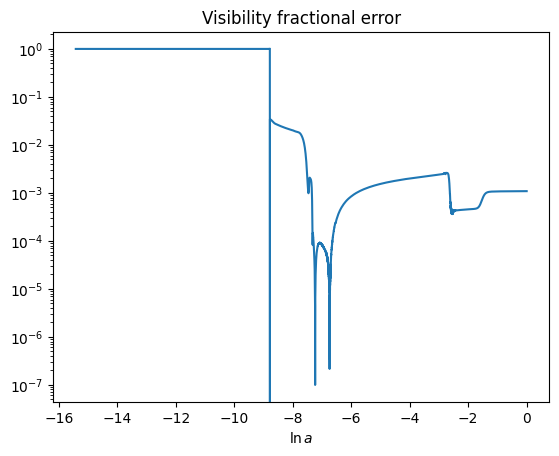

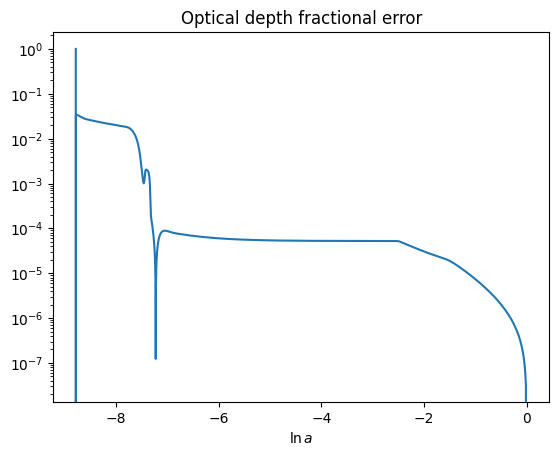

In [222]:
plt.plot(jnp.log(a), g_abcmb)
plt.plot(jnp.log(a), g_class, "--")
plt.show()

plt.plot(jnp.log(a), expmkappa_abcmb)
plt.plot(jnp.log(a), expmkappa_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(g_abcmb-g_class)/g_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("Visibility fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(expmkappa_abcmb-expmkappa_class)/expmkappa_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Optical depth fractional error")
plt.show()

# Perturbations Check

In [80]:
class_pert = class_lcdm.get_perturbations()

In [81]:
cp = class_pert["scalar"][0]

In [82]:
cp.keys()

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm'])

In [112]:
lna_class = jnp.log(cp["a"])
source_class = 2.*cp["shear_g"] + cp["pol0_g"] + cp["pol2_g"]
source_class = jnp.interp(PT.lna, lna_class, source_abcmb)

In [113]:
source_abcmb = 2.*PT.sigma_g[:, 0] + PT.Gg0[:, 0] + PT.Gg2[:, 0]

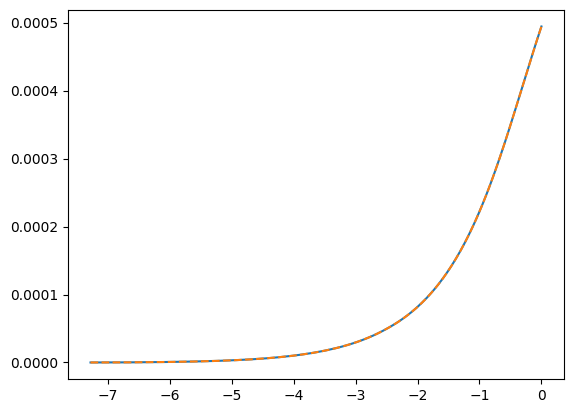

In [114]:
plt.plot(PT.lna, source_class)
plt.plot(PT.lna, source_abcmb, "--")
plt.show()

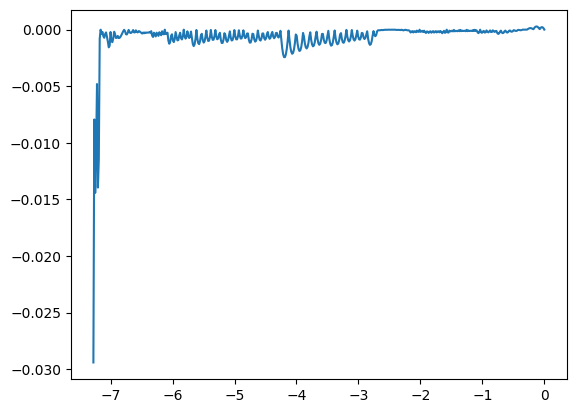

In [115]:
plt.plot(PT.lna, source_abcmb/source_class - 1.)
plt.show()

# Cl's

In [30]:
if specs["lensing"]:
    class_ell = class_lcdm.lensed_cl(lmax)["ell"]
    class_tt = class_lcdm.lensed_cl(lmax)["tt"] * class_ell * (class_ell+1)/2./jnp.pi
    class_te = class_lcdm.lensed_cl(lmax)["te"] * class_ell * (class_ell+1)/2./jnp.pi
    class_ee = class_lcdm.lensed_cl(lmax)["ee"] * class_ell * (class_ell+1)/2./jnp.pi

else:
    class_ell = class_lcdm.raw_cl(lmax)["ell"]
    class_tt = class_lcdm.raw_cl(lmax)["tt"] * class_ell * (class_ell+1)/2./jnp.pi
    class_te = class_lcdm.raw_cl(lmax)["te"] * class_ell * (class_ell+1)/2./jnp.pi
    class_ee = class_lcdm.raw_cl(lmax)["ee"] * class_ell * (class_ell+1)/2./jnp.pi

ells = label[0]
abcmb_tt = ells*(ells+1)/2./jnp.pi * data[0]
abcmb_te = ells*(ells+1)/2./jnp.pi * data[1]
abcmb_ee = ells*(ells+1)/2./jnp.pi * data[2]

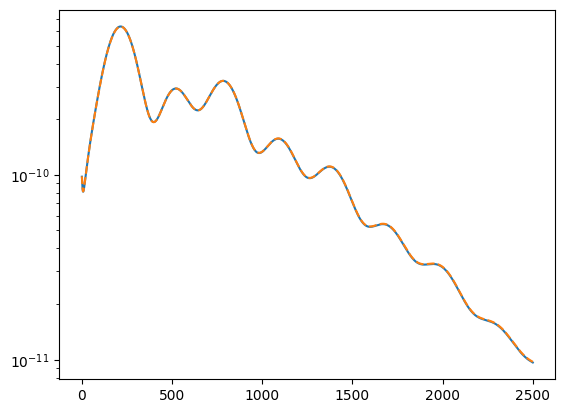

In [31]:
full_l = model.SS.ells
plt.plot(full_l, abcmb_tt)
plt.plot(full_l, class_tt[2:], "--")
plt.yscale("log")
#plt.xlim((2490, 2500))
plt.show()

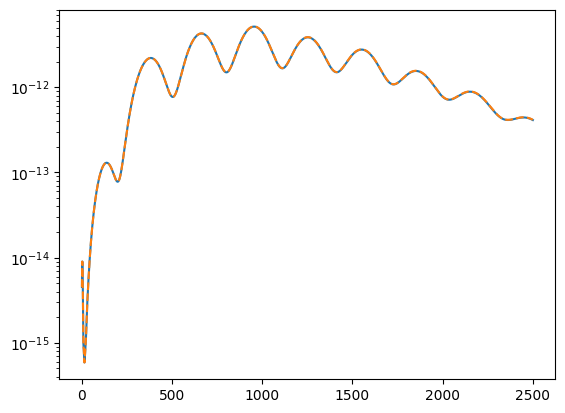

In [32]:
full_l = model.SS.ells
plt.plot(full_l, abcmb_ee)
plt.plot(full_l, class_ee[2:], "--")
plt.yscale("log")
plt.show()

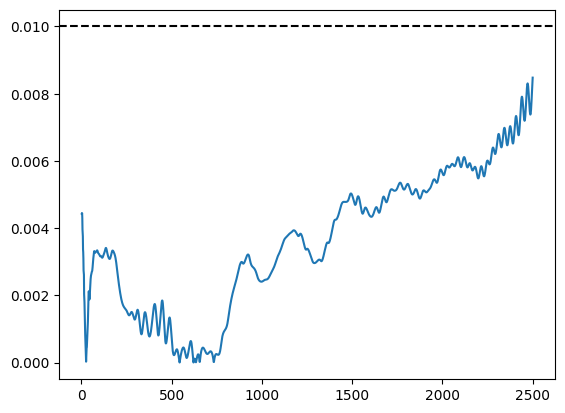

In [33]:
err = abs(abcmb_tt/class_tt[2:] - 1.)
plt.plot(full_l, err)
plt.axhline(0.01, ls="--", color="black")
#plt.yscale("log")
#plt.xscale("log")
plt.show()

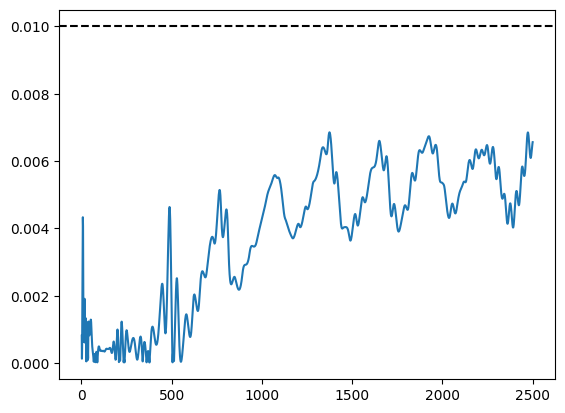

In [34]:
err = abs(abcmb_ee/class_ee[2:] - 1.)
plt.plot(full_l, err)
plt.axhline(0.01, ls="--", color="black")
#plt.yscale("log")
#plt.xscale("log")
plt.show()

In [18]:
model.SS.Cl_one_ell(-1, PT, BG, params)

(Array(9.56255154e-20, dtype=float64),
 Array(-2.56558212e-21, dtype=float64),
 Array(3.99486671e-21, dtype=float64))

In [27]:
class_lcdm.raw_cl(4000)["tt"][-1]

np.float64(8.982238896333272e-20)

In [25]:
model.SS.Cl_one_ell(-1, PT, BG, params)

(Array(8.92491707e-20, dtype=float64),
 Array(-2.80547647e-21, dtype=float64),
 Array(4.04229586e-21, dtype=float64))

In [19]:
idx = -5
l = spectrum.l_tab[idx]
print(l)
myres = model.SS.Cl_one_ell(idx, PT, BG, params)[0]
class_res = class_tt[l] / (l * (l+1)/2./jnp.pi)
print(myres)
print(class_res)
print(abs(myres/class_res - 1.))

3850
1.750686205582872e-19
1.7618537891099486e-19
0.0063385415952808


In [20]:
idx = -5
l = spectrum.l_tab[idx]
print(l)
myres = model.SS.Cl_one_ell(idx, PT, BG, params)[0]
class_res = class_tt[l] / (l * (l+1)/2./jnp.pi)
print(myres)
print(class_res)
print(abs(myres/class_res - 1.))

3850
1.750685490266355e-19
1.7618537891099486e-19
0.006338947597482214


In [22]:
idx = -5
l = spectrum.l_tab[idx]
print(l)
myres = model.SS.Cl_one_ell(idx, PT, BG, params)[0]
class_res = class_tt[l] / (l * (l+1)/2./jnp.pi)
print(myres)
print(class_res)
print(abs(myres/class_res - 1.))

3850
1.7502807330629148e-19
1.7618537891099486e-19
0.006568681305206492


# Lensing

## Lensing Cl

In [30]:
class_pp = class_lcdm.raw_cl(3000)["pp"]
class_tt = class_lcdm.raw_cl(3000)["tt"]
class_te = class_lcdm.raw_cl(3000)["te"]
class_ee = class_lcdm.raw_cl(3000)["ee"]
class_ell = class_lcdm.raw_cl(3000)["ell"]
abcmb_pp = vmap(SS.lensing_Cl, in_axes=(0, None, None))(class_ell, PT, BG)

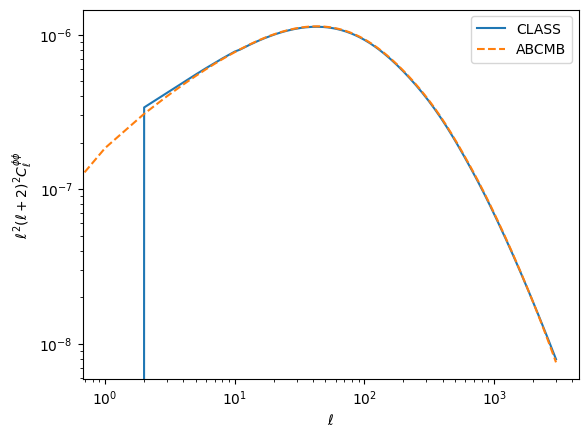

In [31]:
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * class_pp, label="CLASS")
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * abcmb_pp, "--", label="ABCMB")
plt.legend()
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell^2(\ell+2)^2C_\ell^{\phi\phi}$")
plt.show()

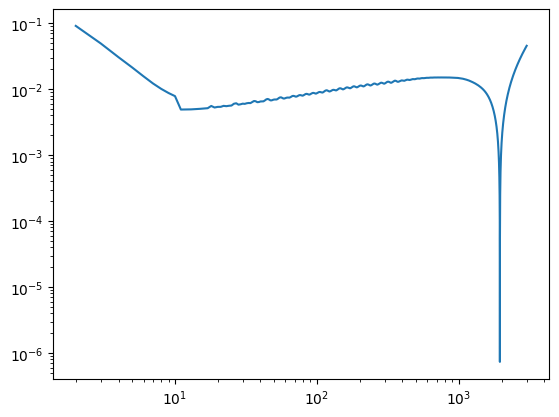

In [32]:
plt.plot(class_ell, abs(class_pp - abcmb_pp)/class_pp)
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.show()

## Temperature Cl

$$
C_\ell = \int_{0.98}^{1} \xi(\beta) J_0(\ell \beta) d\cos{\beta}
$$

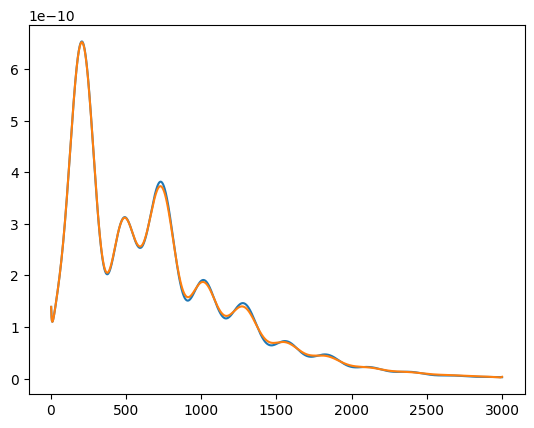

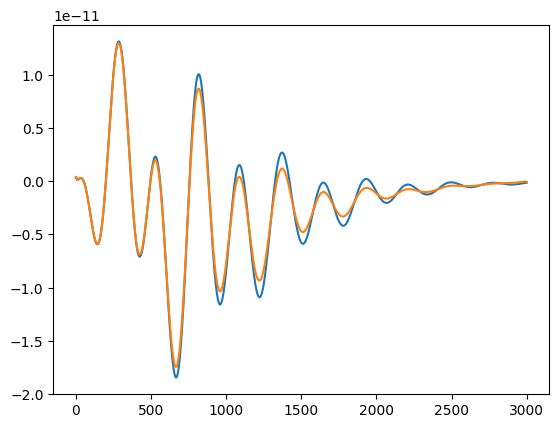

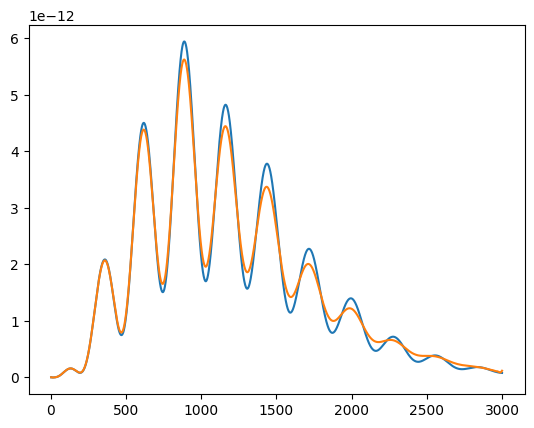

In [36]:
#res = SS.lense_ClTT(class_ell[2:], class_pp[2:], class_ell[2:]*(class_ell[2:]+1)*class_tt[2:]/2./jnp.pi)
#plt.loglog(class_ell[2:], class_ell[2:]*(class_ell[2:]+1)*res)
#ells = jnp.arange(2, 2000)
ells = class_ell[2:]
cltt = class_tt[2:]
clte = class_te[2:]
clee = class_ee[2:]
clpp = class_pp[2:]
pref = ells*(ells+1)/2./jnp.pi
#clpp = jnp.zeros(ells.size)
res_tt, res_te, res_ee = eqx.filter_jit(SS.lensed_Cls)(ells, cltt, clte, clee, PT, BG)
plt.plot(ells, pref*cltt)
plt.plot(ells, pref*(res_tt+cltt))
plt.show()

plt.plot(ells, pref*clte)
plt.plot(ells, pref*(res_te+clte))
plt.show()

plt.plot(ells, pref*clee)
plt.plot(ells, pref*(res_ee+clee))
plt.show()

In [47]:
f = eqx.filter_jit(SS.lensed_Cls)
for i in range(2):
    s = time.time()
    res_tt, res_te, res_ee = f(ells, cltt, clte, clee, PT, BG)
    res_tt.block_until_ready()
    print(time.time() - s)

16.553486347198486
11.142034769058228


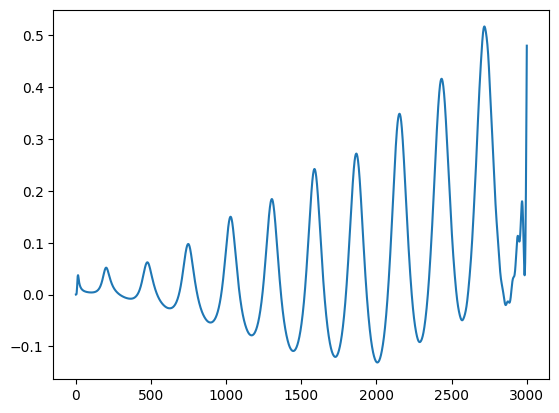

In [304]:
#plt.plot(ells, res_tt/cltt)
#plt.plot(ells, res_te/clte)
plt.plot(ells, res_ee/clee)
plt.show()

## Wigner Matrices

In [104]:
f = jit(tools.lensing_d00)
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1003)
mu    = jnp.cos(betas)
print(f(mu, l).shape)

(1000, 1001)


In [55]:
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1000)
mu    = jnp.cos(betas)

d00  = tools.lensing_d00(mu, l)
d11  = tools.lensing_d11(mu, l)
d1m1 = tools.lensing_d1m1(mu, l)
d2m2 = tools.lensing_d2m2(mu, l)

In the large $\ell$ limit, the Wigner matrices approach Bessel J functions as
$$
\lim_{\ell\rightarrow \infty}d_{mn}^{\ell}(\beta) \longrightarrow (-1)^{n-m} J_{m-n}(\ell \beta)\, .
$$
It serves to check the asymptotic behavior to make sure the recursion relations were correct.

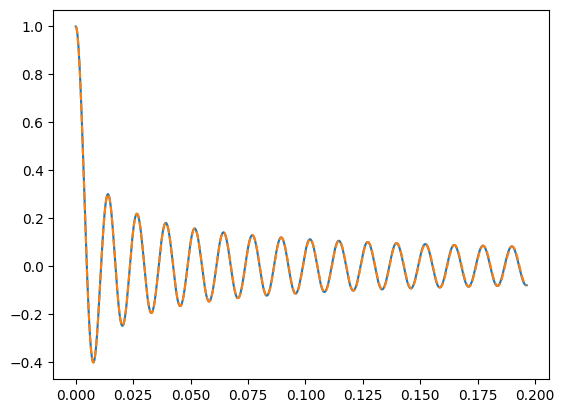

In [19]:
l = 500
plt.plot(betas, d00[:, l-2])
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

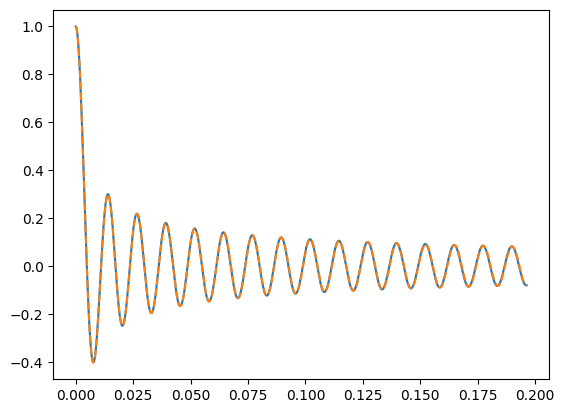

In [20]:
l = 500
plt.plot(betas, d11[:, l-2], label="d11")
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

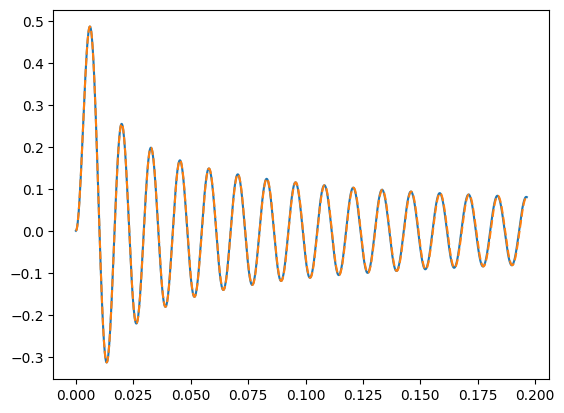

In [21]:
l = 500
plt.plot(betas, d1m1[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(2, l*betas), "--")
plt.show()

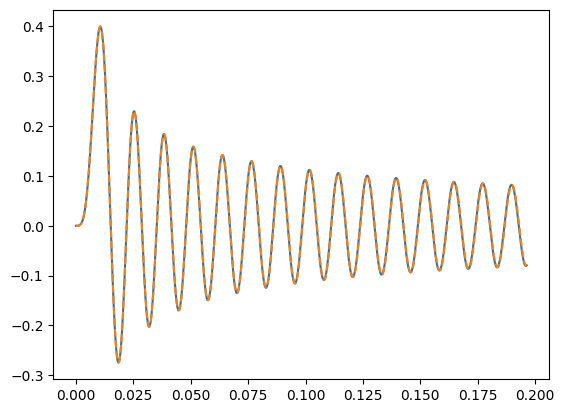

In [62]:
l = 500
plt.plot(betas, d2m2[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(4, l*betas), "--")
plt.show()

In [233]:
# Attempt at general solution
def wigner_d_matrix(mu, ells, m, n):
    """
    m, n are integers. m must be positive and greater than n.
    ells an array ([m, m+1, m+2, ..., ellmax])
    """
    
    # base case: ell = m
    def base_val(mu):
        beta = jnp.arccos(mu)
        norm = jnp.sqrt((2*m+1)/2) * jnp.sqrt(factorial(2*m)/(factorial(m+n)*factorial(m-n)))
        return norm * jnp.cos(beta/2.)**(m+n)*(-jnp.sin(beta/2.))**(m-n)
        #return norm * jnp.sqrt((1+mu)/2)**(m+n) * jnp.sqrt((1-mu)/2)**(m-n)

    normA = jnp.sqrt((2*ells+3)/(2*ells+1))
    normC = jnp.sqrt((2*ells+3)/(2*ells-1))
    denom = jnp.sqrt((ells+1)**2-m**2) * jnp.sqrt((ells+1)**2-n**2)
    A = jnp.nan_to_num(normA * (ells+1)*(2*ells+1) / denom, 0)
    B = jnp.nan_to_num(-A * m * n / ells / (ells+1), 0)
    C = jnp.nan_to_num(-normC * jnp.sqrt(ells**2-m**2) * jnp.sqrt(ells**2-n**2) / denom * (ells+1)/ells, 0)

    def one_mu(mu):
        d_start = base_val(mu) # Corresponds to ellmin = m
                
        def recursive_dlp1(carry, inputs):
            # For the first iteration, will take d1 and d2, compute d3.
            dl, dlm1 = carry 
            a, b, c = inputs

            # Compute dlp1
            dlp1 = a*mu*dl + b*dl + c*dlm1

            # Save dl, then make dl->dlm1, dlp1->dl
            return (dlp1, dl), dl

        # run scan for l = 2..lmax-1
        (_, _), res = lax.scan(recursive_dlp1, (d_start, 0.), (A, B, C))
        return res * jnp.sqrt(2./(2.*ells+1))

    return vmap(one_mu)(mu)

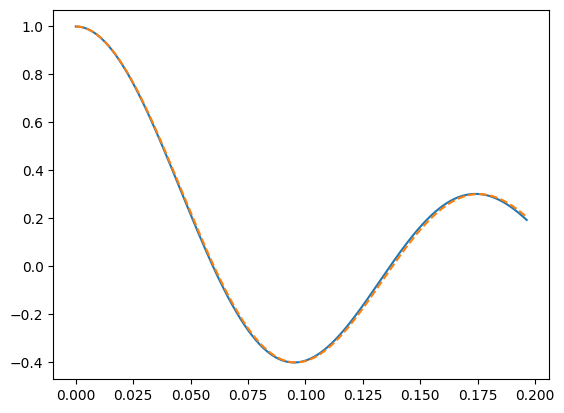

In [245]:
m = 4
n = 4
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(m, 1000)
mu    = jnp.cos(betas)
d = jit(wigner_d_matrix)(mu, l, m, n)

l_plot = 10*m
plt.plot(betas, d[:, l_plot-m])
plt.plot(betas, (-1)**(n-m)*scipy.special.jv(m-n, l_plot*betas), "--")
plt.show()

In [248]:
d.shape
zeros = jnp.zeros((mu.size, m-2))
d_patched = jnp.concatenate((zeros, d), axis=1)

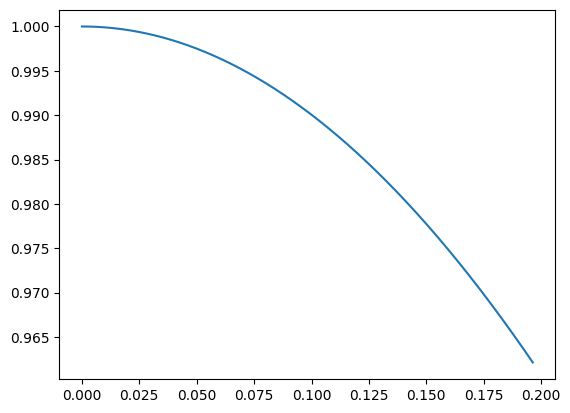

In [252]:
plt.plot(betas, d_patched[:, 2])

In [280]:
arr = jnp.ones(5)

5